In [2]:
from datasets import load_dataset

dataset = load_dataset("ag_news")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [3]:
import pandas as pd

df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

print(f"Training samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")
df_train.head()

Training samples: 120000
Test samples: 7600


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [4]:
label_names = dataset["train"].features["label"].names
print("Labels:", label_names)

Labels: ['World', 'Sports', 'Business', 'Sci/Tech']


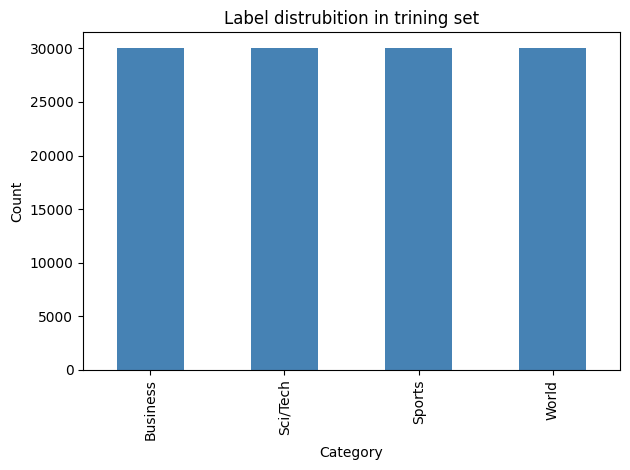

In [5]:
import matplotlib.pyplot as plt
df_train["label_name"] = df_train["label"].map(lambda x: label_names[x])
df_train["label_name"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Label distrubition in trining set")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../data/labeldistrubition.png")
plt.show()

In [6]:
df_train["text_length"] = df_train["text"].apply(len)
df_train["text_length"].describe()

count    120000.000000
mean        236.477525
std          66.509741
min         100.000000
25%         196.000000
50%         232.000000
75%         266.000000
max        1012.000000
Name: text_length, dtype: float64

In [7]:
for label in df_train["label_name"].unique():
	sample = df_train[df_train["label_name"] == label].iloc[0]["text"]
	print(f"\n📰 [{label}]\n{sample[:300]}\n{'─'*60}")


📰 [Business]
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
────────────────────────────────────────────────────────────

📰 [Sci/Tech]
'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because "Madden NFL 2005" came out that day,\and some fans of the football simulation are rabid enough to\take a sick day 
────────────────────────────────────────────────────────────

📰 [Sports]
Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's 400 freestyle relay final. Phelps' rivals Ian Thorpe and Pieter van den Hoogenba
────────────────────────────────────────────────────────────

📰 [World]
Venezuelans Vote Ea

In [8]:
print("Missing Values:\n", df_train.isnull().sum())
print("\nEmpty Strings:", (df_train["text"]=="").sum())

Missing Values:
 text           0
label          0
label_name     0
text_length    0
dtype: int64

Empty Strings: 0


In [9]:
import re
def clean_text(text):
    text = text.lower()
    text= re.sub(r"http\S+","",text)
    text = re.sub(r"[^a-z0-9\s]","",text)
    text = re.sub(r"\s+"," ", text).strip()
    return text

sample=df_train["text"].iloc[0]
print("BEFORE:\n", sample[:300])
print("\nAfter:\n", clean_text(sample)[:300])

BEFORE:
 Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

After:
 wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again


In [10]:
df_train["clean_text"] = df_train["text"].apply(clean_text)
df_test["clean_text"] = df_test["text"].apply(clean_text)

print("Cleaned!")
print(df_train[["text", "clean_text"]].head(3))

Cleaned!
                                                text  \
0  Wall St. Bears Claw Back Into the Black (Reute...   
1  Carlyle Looks Toward Commercial Aerospace (Reu...   
2  Oil and Economy Cloud Stocks' Outlook (Reuters...   

                                          clean_text  
0  wall st bears claw back into the black reuters...  
1  carlyle looks toward commercial aerospace reut...  
2  oil and economy cloud stocks outlook reuters r...  


In [11]:
df_train.to_csv("../data/train_clean.csv", index=False)
df_test.to_csv("../data/test_clean.csv", index=False)

print("Saved to data/ folder")

Saved to data/ folder
